In [1]:
# Section 0: Setup
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
# Force pandas to show regular floats instead of scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [ ]:
# Section 0: Data principles, encoded as config so every downstream calc references the same
# assumptions instead of re-deciding them inline.
CONFIG = {
    # --- Scope for production and trade --- 
    #We are interested only in cotton for fiber purposes and Primary analysis: QCL 767 production ↔ TCL 767 exports
    #Supporting analysis: QCL 328 seed cotton → QCL 767 lint to understand the cotton-fiber conversion.
    'crop_item_code': 767,        # FAOSTAT Item Code for Cotton 
    'crop_name': 'Cotton lint; ginned',

   # --- Scope for trade ----
   # Rice with item code 113 (in QCL data) is not traded straight forward as 113, 
   # it inturn is traded in multiple forms (Rice;milled and Rice; milled (husked) as layer 1 and 2) 
   # and there is a conversion factor associated with this
   # Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content (page 723)
   # Can be navigated from: https://openknowledge.fao.org/home 
   # The reason for this conversion also comes from this paper:
   # https://www.fao.org/fileadmin/templates/mafap/documents/Methodological_Guidelines/Methodological_Guidelines_-_Volume_I_-_Price_Incentives_-_Final.pdf (page 23)
   # Keyed by the CPC code as it appears in Trade_CropsLivestock_E_ItemCodes. 
   # The 
    # 'trade_crop_item_code': 767,
    # 'trade_crop_name_rm' : 'Cotton lint; ginned',


    # # --- Years ---
    # # Single-year production/trade figures are noisy (one bad harvest, one reporting gap).
    # # Use a trailing N-year average, anchored to the latest year with broad country coverage,
    # # for anything used to rank/classify countries. Time-series charts still use the full history.
    # 'trailing_avg_years': 3,

    # --- Drop Area codes----
    # Excluding regional/continental aggregates (<5000)
    # Table above has an explaination about how China's area codes are represented in the FAOSTAT datset
    'aggregate_code_cutoff': 5000,
    'exclude_area_codes': [351, 357,214,96,128],

    # --- Scope of "major producer" / "major supplier" ---
    'top_n_producers': 15,        
    'top_n_exporters': 15, 
    'top_n_importers_display': 15,

    # --- Imputation / exclusion rules ---
    # - Drop FAOSTAT regional/continental aggregates (Area/Reporter/Partner Code >= 5000) everywhere
}

# Caveat repeated throughout the brief: FAOSTAT does not separate brewing barley from feed/food
# barley. Every number in this notebook is total barley; beer is the storytelling frame, not the
# analytical scope.
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


{
  "crop_item_code": 767,
  "crop_name": "Cotton lint; ginned",
  "trade_crop_item_code": 767,
  "trade_crop_name_rm": "Cotton lint; ginned",
  "aggregate_code_cutoff": 5000,
  "exclude_area_codes": [
    351,
    357,
    214,
    96,
    128
  ],
  "top_n_producers": 15,
  "top_n_exporters": 15,
  "top_n_importers_display": 15
}


### Section 1a: QCL data analysis: How much cotton fiber does each country produce?

In [3]:
# Section 1a: QCL bulk download (Production: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full QCL: {len(qcl_all):,} rows')

Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows


In [ ]:
# Section 1b: verify the Cotton item code before trusting it — same discipline as the original
# notebook's Section 2 (codes get hardcoded once and then never re-checked otherwise).
# Don't assume the code is 767: derive it from this file's own lookup table, the same way
cotton_matches = item_codes[item_codes['Item'].str.contains('Cotton', case=False, na=False)][['Item Code', 'Item']]
print(cotton_matches.to_string(index=False))

exact = cotton_matches[cotton_matches['Item'].str.fullmatch('Cotton lint; ginned', case=False)]
print(exact)
if len(exact):
    CONFIG['crop_item_code'] = int(exact.iloc[0]['Item Code'])
else:
    print("No exact 'Cotton' match in the lookup — check the table above and set CONFIG['crop_item_code'] manually.")
    CONFIG['crop_item_code'] = int(cotton_matches.iloc[0]['Item Code'])  # best-effort fallback

print(f"Using Item Code {CONFIG['crop_item_code']} for Cotton")

Item Code                  Item
      767   Cotton lint; ginned
      329           Cotton seed
      331        Cottonseed oil
      328 Seed cotton; unginned
   Item Code                 Item
70       767  Cotton lint; ginned
Using Item Code 767 for Cotton


In [16]:
# Section 1c: filter to Cotton Lint, ginned Production (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
# Area Code isin() cast to str on both sides — the dtype mismatch here was the bug fixed in the
# original notebook's Section 3; keeping the cast explicit rather than trusting pandas to infer it.
qcl_cotton = qcl_all[(qcl_all['Item Code'] == CONFIG['crop_item_code']) & (qcl_all['Element'] == 'Production')].copy()
print(f"Cotton lint(ginned), Production element: {len(qcl_cotton):,} rows, unit(s): {qcl_cotton['Unit'].unique()}")
# print(qcl_cotton.head())

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

qcl_cotton = qcl_cotton[qcl_cotton['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(qcl_cotton):,} rows, {qcl_cotton['Area'].nunique()} countries")
# print(qcl_cotton.tail())

cotton_by_area_year = qcl_cotton.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='production_t')

Cotton lint(ginned), Production element: 7,903 rows, unit(s): ['t']
After dropping aggregates + doubly counted codes (for China): 5,986 rows, 104 countries


In [23]:
world_cotton_production = cotton_by_area_year['production_t'].sum()
print(f"Total worlds cotton production for fiber is Cotton lint; ginned and the total production is: {world_cotton_production} t")

world_cotton_production_yearwise = cotton_by_area_year.groupby('Year')['production_t'].sum().reset_index()
print(f"Total worlds cotton production for fiber is Cotton lint; ginned and the total production is: {world_cotton_production_yearwise} t")

Total worlds cotton production for fiber is Cotton lint; ginned and the total production is: 1148819570.85 t
Total worlds cotton production for fiber is Cotton lint; ginned and the total production is:     Year  production_t
0   1961    9461557.26
1   1962   10214135.76
2   1963   11232301.71
3   1964   11721864.65
4   1965   12420334.91
..   ...           ...
58  2019   25161668.24
59  2020   24355499.59
60  2021   25106553.38
61  2022   25128242.17
62  2023   24702181.79

[63 rows x 2 columns] t


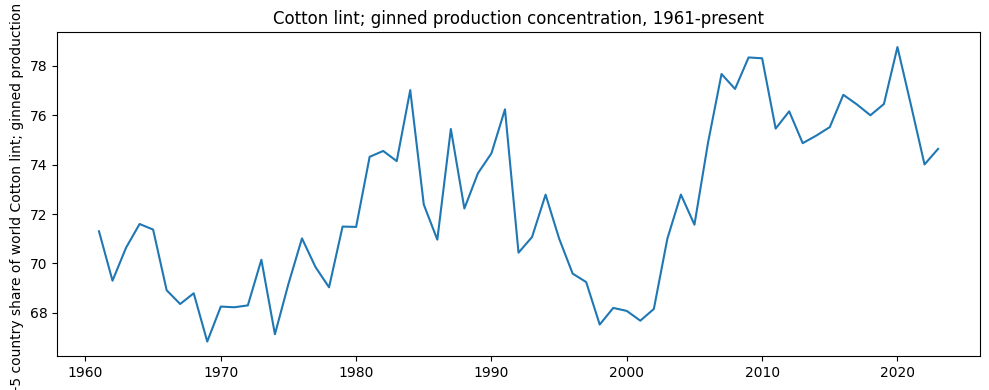

Latest top-5 share: 74.6%


In [22]:
# Full-history concentration trend (top-5 share of world production, year by year) — same metric
# as the original cotton_by_area_year's Section 4, recomputed here for Cotton alone.
by_year_rank = cotton_by_area_year.copy()
by_year_rank['rank'] = by_year_rank.groupby('Year')['production_t'].rank(ascending=False, method='min')

global_total_by_year = cotton_by_area_year.groupby('Year')['production_t'].sum().reset_index(name='global_total')
top5_by_year = (by_year_rank[by_year_rank['rank'] <= 5]
                .groupby('Year')['production_t'].sum().reset_index(name='top5_total'))
concentration = top5_by_year.merge(global_total_by_year, on='Year')
concentration['top5_share_pct'] = concentration['top5_total'] / concentration['global_total'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(concentration['Year'], concentration['top5_share_pct'])
ax.set_ylabel(f"Top-5 country share of world {CONFIG['crop_name']} production (%)")
ax.set_title(f"{CONFIG['crop_name']} production concentration, 1961-present")
plt.tight_layout(); plt.show()

print(f"Latest top-5 share: {concentration.sort_values('Year').iloc[-1]['top5_share_pct']:.1f}%")


#### Analysing the production (Total and Avg) for countries over a period of 2000-2024

In [ ]:
#This is the total production analysis
# This matches with the total cotton lint; ginned on the website
cotton_production_total = (
    cotton_by_area_year
    .groupby('Area')['production_t']
    .sum()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(cotton_production_total)

                                Area  production_t
20                   China, mainland  266070770.00
95          United States of America  204621427.00
45                             India  163181785.21
67                          Pakistan   81884240.00
92                              USSR   73242000.00
..                               ...           ...
38                           Grenada       1069.03
75             Saint Kitts and Nevis        910.70
76  Saint Vincent and the Grenadines        564.30
72               Republic of Moldova          0.00
80                       South Sudan          0.00

[104 rows x 2 columns]


In [25]:
#This is the total production analysis
cotton_production_2000_2024 = (
    cotton_by_area_year[
        (cotton_by_area_year['Year'] >= 2000) &
        (cotton_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .sum()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(cotton_production_2000_2024)

                                Area  production_t
20                   China, mainland  143502140.00
44                             India  108548035.21
92          United States of America   89943619.00
66                          Pakistan   44712029.00
12                            Brazil   36396823.47
..                               ...           ...
23                              Cuba          0.00
78                       South Sudan          0.00
49                             Italy          0.00
28                Dominican Republic          0.00
74  Saint Vincent and the Grenadines          0.00

[100 rows x 2 columns]


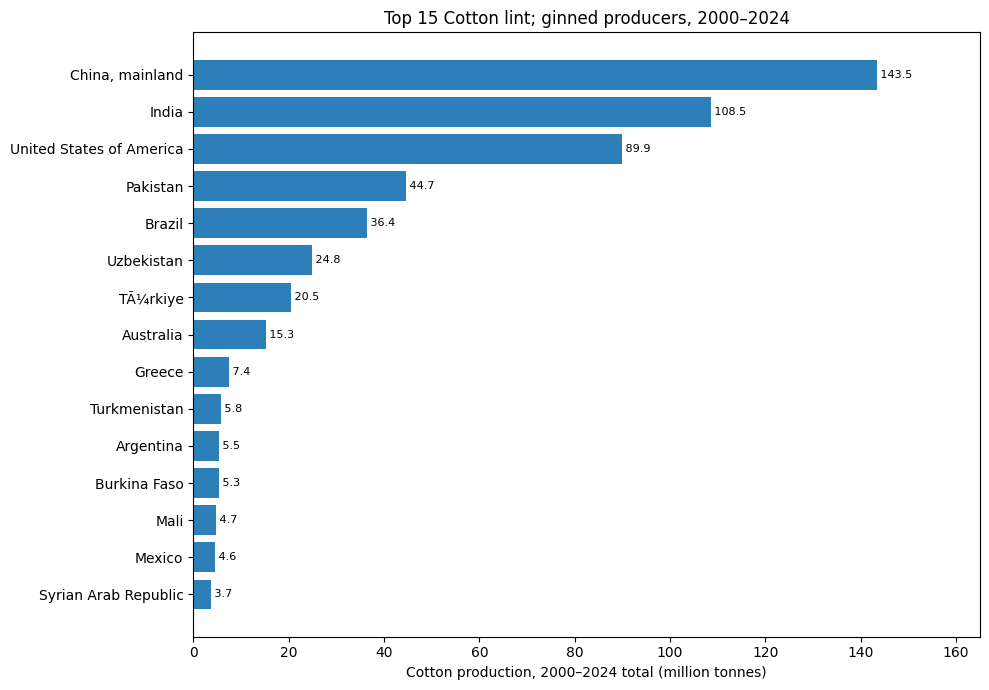

In [27]:
#Plotting the above data in bar-chart format
top = cotton_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Cotton production, 2000–2024 total (million tonnes)")
plt.title(f"Top 15 {CONFIG['crop_name']} producers, 2000–2024")

for y, v in enumerate(top['production_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

### This analysis is essential for section 2

In [71]:
# Add each country's share of total world cotton production, 2000-2024
cotton_production_2000_2024['pct_share_production'] = (
    cotton_production_2000_2024['production_t']
    / cotton_production_2000_2024['production_t'].sum()
    * 100
)

# Re-sort and assign rank
cotton_production_2000_2024 = (
    cotton_production_2000_2024
    .sort_values('production_t', ascending=False)
    .reset_index(drop=True)
)

cotton_production_2000_2024['rank'] = (
    cotton_production_2000_2024.index + 1
)

print(cotton_production_2000_2024)

                                Area  production_t  pct_share_production  rank
0                    China, mainland  143502140.00                 25.27     1
1                              India  108548035.21                 19.11     2
2           United States of America   89943619.00                 15.84     3
3                           Pakistan   44712029.00                  7.87     4
4                             Brazil   36396823.47                  6.41     5
..                               ...           ...                   ...   ...
95                        Guadeloupe          0.00                  0.00    96
96                           Romania          0.00                  0.00    97
97                 Republic of Korea          0.00                  0.00    98
98                            Cyprus          0.00                  0.00    99
99  Saint Vincent and the Grenadines          0.00                  0.00   100

[100 rows x 4 columns]


In [67]:
#This is the average production 
avg_cotton_production_2000_2024 = (
    cotton_by_area_year[
        (cotton_by_area_year['Year'] >= 2000) &
        (cotton_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .mean()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(avg_cotton_production_2000_2024)

                                Area  production_t
20                   China, mainland    5979255.83
44                             India    4522834.80
92          United States of America    3747650.79
66                          Pakistan    1863001.21
12                            Brazil    1516534.31
..                               ...           ...
74  Saint Vincent and the Grenadines          0.00
72                            Rwanda          0.00
71                           Romania          0.00
70                 Republic of Korea          0.00
28                Dominican Republic          0.00

[100 rows x 2 columns]


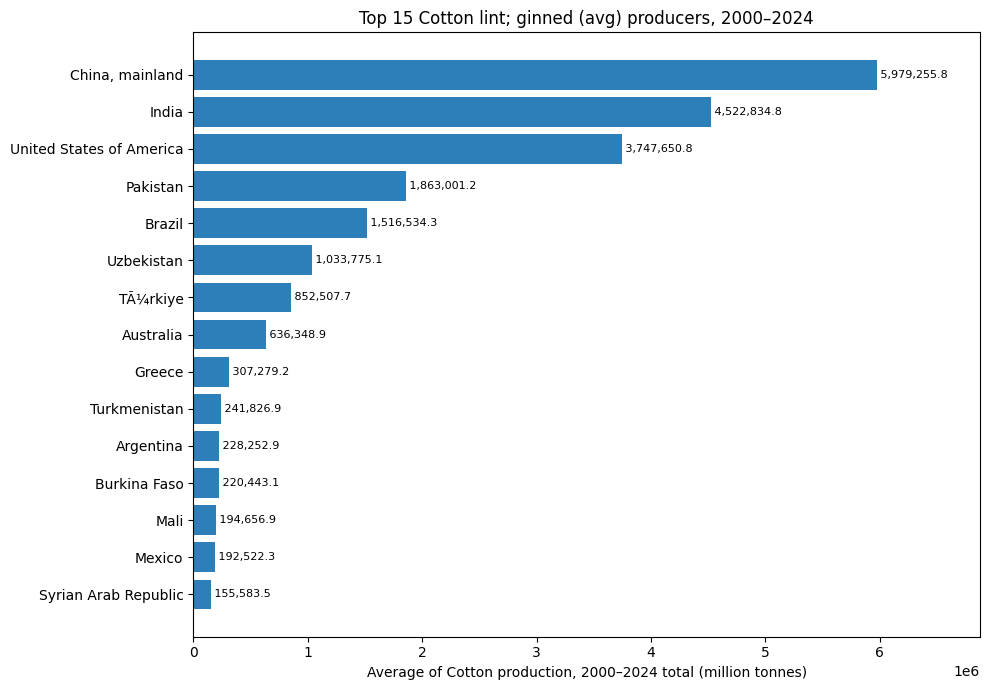

In [68]:
#Plotting the above data in bar-chart format
top = avg_cotton_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'], color="#2C7FB8")
plt.xlabel("Average of Cotton production, 2000–2024 total (million tonnes)")
plt.title(f"Top 15 {CONFIG['crop_name']} (avg) producers, 2000–2024")

for y, v in enumerate(top['production_t']):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [69]:
#Adding the world percentage values and ranks in terms of average production
avg_cotton_production_2000_2024['pct_of_world_production'] = (
    avg_cotton_production_2000_2024['production_t']
    / avg_cotton_production_2000_2024['production_t'].sum() * 100
)

avg_cotton_production_2000_2024 = avg_cotton_production_2000_2024.reset_index(drop=True)
avg_cotton_production_2000_2024['rank'] = avg_cotton_production_2000_2024.index + 1

print(avg_cotton_production_2000_2024)

                                Area  production_t  pct_of_world_production  rank
0                    China, mainland    5979255.83                    25.17     1
1                              India    4522834.80                    19.04     2
2           United States of America    3747650.79                    15.78     3
3                           Pakistan    1863001.21                     7.84     4
4                             Brazil    1516534.31                     6.38     5
..                               ...           ...                      ...   ...
95  Saint Vincent and the Grenadines          0.00                     0.00    96
96                            Rwanda          0.00                     0.00    97
97                           Romania          0.00                     0.00    98
98                 Republic of Korea          0.00                     0.00    99
99                Dominican Republic          0.00                     0.00   100

[100 rows x 4 c

### Section 1b: TCL data analysis: How much of produced cotton fiber enters international trade?

In [36]:
# TCL bulk download (Trade: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Trade_CropsLivestock_E_All_Data_(Normalized).zip'
if not os.path.exists('tcl_bulk.zip'):
    print('Downloading TCL bulk file (~261 MB, a few minutes)...')
    urllib.request.urlretrieve(BULK_URL, 'tcl_bulk.zip')

with zipfile.ZipFile('tcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n
                and 'Elements' not in n][0]
    print(f'Reading {csv_name}...')
    tcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    tcl_item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    tcl_area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full TCL: {len(tcl_all):,} rows')

Reading Trade_CropsLivestock_E_All_Data_(Normalized).csv...
Full TCL: 17,143,873 rows


In [37]:
print(tcl_all.head())

   Area Code Area Code (M49)         Area  Item Code Item Code (CPC)               Item  Element Code  \
0          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
1          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
2          3            '008      Albania        221          '01371  Almonds, in shell          5610   
3          4            '012      Algeria        221          '01371  Almonds, in shell          5610   
4          3            '008      Albania        221          '01371  Almonds, in shell          5610   

           Element  Year Code  Year Unit  Value Flag                                            Note  
0  Import quantity       2014  2014    t  34.46    X  Estimated data using trading partners database  
1  Import quantity       2015  2015    t  75.50    X  Estimated data using trading partners database  
2  Import quantity       1996  1996    t  87.00    A        

In [38]:
# Section 1b: verify the Cotton item code before trusting it — same discipline as the original
# notebook's Section 2 (codes get hardcoded once and then never re-checked otherwise).
# Don't assume the code is 767: derive it from this file's own lookup table, the same way
cotton_matches = item_codes[item_codes['Item'].str.contains('Cotton', case=False, na=False)][['Item Code', 'Item']]
print(cotton_matches.to_string(index=False))

exact = cotton_matches[cotton_matches['Item'].str.fullmatch('Cotton lint; ginned', case=False)]
print(exact)
if len(exact):
    CONFIG['crop_item_code'] = int(exact.iloc[0]['Item Code'])
else:
    print("No exact 'Cotton' match in the lookup — check the table above and set CONFIG['crop_item_code'] manually.")
    CONFIG['crop_item_code'] = int(cotton_matches.iloc[0]['Item Code'])  # best-effort fallback

print(f"Using Item Code {CONFIG['crop_item_code']} for Cotton")

Item Code                  Item
      767   Cotton lint; ginned
      329           Cotton seed
      331        Cottonseed oil
      328 Seed cotton; unginned
   Item Code                 Item
70       767  Cotton lint; ginned
Using Item Code 767 for Cotton


In [46]:
# Section 1c: filter to Rice Production (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
tcl_cotton = tcl_all[(tcl_all['Item Code'] == CONFIG['crop_item_code']) & (tcl_all['Element'] == 'Export quantity')].copy()
print(f"Cotton lint(ginned) Export element: {len(tcl_cotton):,} rows, unit(s): {tcl_cotton['Unit'].unique()}, \
        countries: {tcl_cotton['Area'].nunique()}")
# print(tcl_cotton.head())

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

tcl_cotton = tcl_cotton[tcl_cotton['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(tcl_cotton):,} rows, {tcl_cotton['Area'].nunique()} countries")
# # print(tcl_cotton.head())

cotton_by_area_year_traded = tcl_cotton.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='exported_t')

Cotton lint(ginned) Export element: 11,509 rows, unit(s): ['t'],         countries: 257
After dropping aggregates + doubly counted codes (for China): 8,053 rows, 180 countries


In [48]:
cotton_by_area_year_traded

,Area,Area Code,Year,exported_t
0,Afghanistan,2,1961,11480.00
1,Afghanistan,2,1962,11380.00
2,Afghanistan,2,1963,17118.00
3,Afghanistan,2,1964,21043.00
4,Afghanistan,2,1965,15903.00
...,...,...,...,...
8048,Zimbabwe,181,2020,23213.58
8049,Zimbabwe,181,2021,52322.86
8050,Zimbabwe,181,2022,21447.60
8051,Zimbabwe,181,2023,19519.10


In [51]:
# World cotton traded per year in tonnes
world_trade_over_year = cotton_by_area_year_traded.groupby('Year')['exported_t'].sum().reset_index()
print(world_trade_over_year)

# #Export share
# export_share = (world_trade_over_year['exported_t']/world_production_over_year['production_t']) * 100
# print(export_share)


    Year  exported_t
0   1961  3753357.00
1   1962  3403034.00
2   1963  3759648.00
3   1964  3937027.00
4   1965  3778613.00
..   ...         ...
59  2020  9387977.77
60  2021  9739709.18
61  2022  9177945.97
62  2023  8138679.30
63  2024  9140191.03

[64 rows x 2 columns]


#### Which countries exported the most cotton over the entire 2000–2024 period? 
Note: Top exporters, shown below are based on the the FAOSTAT Cotton lint;ginned  trade classification.

In [81]:
#Total exports of cotton lint,ginned (code 767) between 2000-2024
cotton_exports_2000_2024 = (
    cotton_by_area_year_traded[
        (cotton_by_area_year_traded['Year'] >= 2000) &
        (cotton_by_area_year_traded['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .sum()
    .reset_index()
    .rename(columns={'exported_t': 'total_exported_t'})
    .sort_values('total_exported_t', ascending=False)
)

print(cotton_exports_2000_2024)


                         Area  total_exported_t
164  United States of America       71115109.35
72                      India       22856460.34
22                     Brazil       21930373.35
7                   Australia       17276477.74
166                Uzbekistan       10086293.18
..                        ...               ...
38                       Cuba              0.00
96                      Malta              0.00
129     Saint Kitts and Nevis              0.00
130               Saint Lucia              0.00
132     Sao Tome and Principe              0.00

[172 rows x 2 columns]


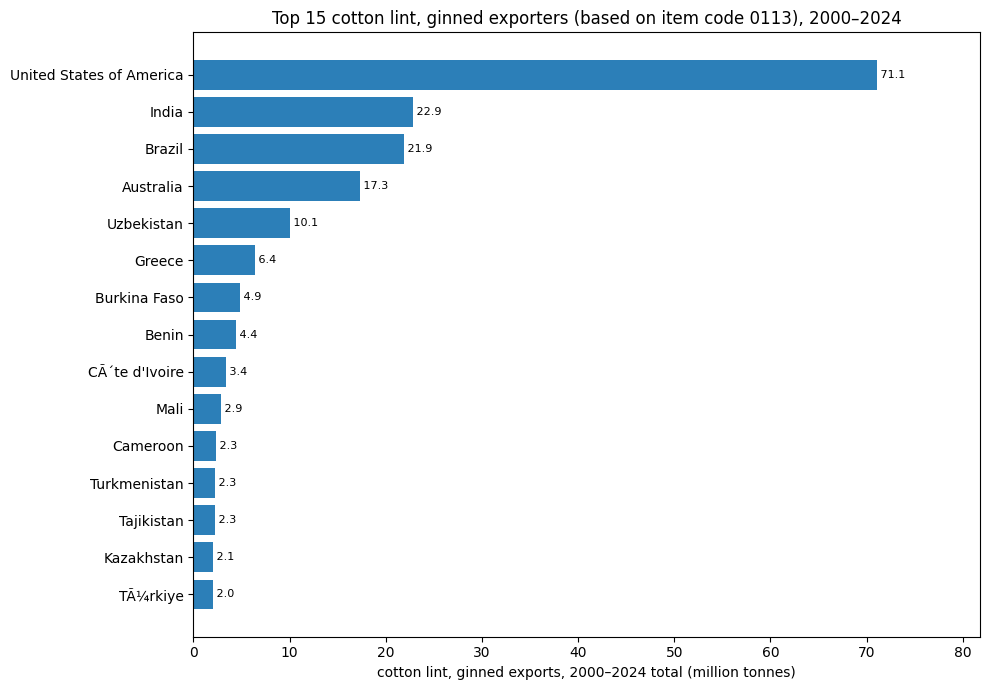

In [82]:
#Plotting the above data in bar chart
top = cotton_exports_2000_2024.nlargest(15, 'total_exported_t').sort_values('total_exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['total_exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("cotton lint, ginned exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 cotton lint, ginned exporters (based on item code 0113), 2000–2024")

for y, v in enumerate(top['total_exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [83]:
cotton_exports_2000_2024['pct_of_world_exports'] = (
    cotton_exports_2000_2024['total_exported_t']
    / cotton_exports_2000_2024['total_exported_t'].sum()
    * 100
)

cotton_exports_2000_2024 = (
    cotton_exports_2000_2024
    .sort_values('total_exported_t', ascending=False)
    .reset_index(drop=True)
)

cotton_exports_2000_2024['rank'] = (
    cotton_exports_2000_2024.index + 1
)

print(cotton_exports_2000_2024)

                         Area  total_exported_t  pct_of_world_exports  rank
0    United States of America       71115109.35                 35.52     1
1                       India       22856460.34                 11.42     2
2                      Brazil       21930373.35                 10.95     3
3                   Australia       17276477.74                  8.63     4
4                  Uzbekistan       10086293.18                  5.04     5
..                        ...               ...                   ...   ...
167                      Cuba              0.00                  0.00   168
168                     Malta              0.00                  0.00   169
169     Saint Kitts and Nevis              0.00                  0.00   170
170               Saint Lucia              0.00                  0.00   171
171     Sao Tome and Principe              0.00                  0.00   172

[172 rows x 4 columns]


In [55]:
#Average exports of cotton (code 27) between 2000-2024
average_cotton_exports_2000_2024 = (
    cotton_by_area_year_traded[
        (cotton_by_area_year_traded['Year'] >= 2000) &
        (cotton_by_area_year_traded['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .mean()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(average_cotton_exports_2000_2024)


                         Area  exported_t
164  United States of America  2844604.37
72                      India   914258.41
22                     Brazil   877214.93
7                   Australia   691059.11
166                Uzbekistan   403451.73
..                        ...         ...
38                       Cuba        0.00
137              Sierra Leone        0.00
132     Sao Tome and Principe        0.00
130               Saint Lucia        0.00
129     Saint Kitts and Nevis        0.00

[172 rows x 2 columns]


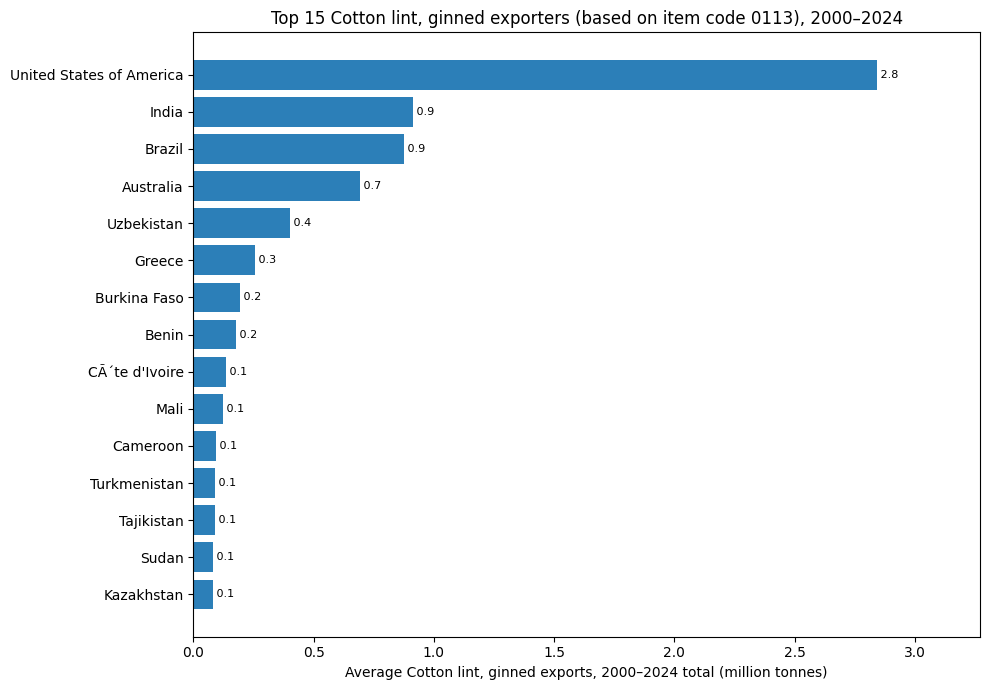

In [58]:
#Plotting the above data in bar chart
top = average_cotton_exports_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average Cotton lint, ginned exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 Cotton lint, ginned exporters (based on item code 0113), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate each country's share of average annual world exports, 2000-2024
# This is still similar to total world exports of cotton between 2000-2024 since the 
average_cotton_exports_2000_2024['pct_of_world_exports'] = (
    average_cotton_exports_2000_2024['exported_t']
    / average_cotton_exports_2000_2024['exported_t'].sum() * 100
)

average_cotton_exports_2000_2024 = average_cotton_exports_2000_2024.reset_index(drop=True)
average_cotton_exports_2000_2024['rank'] = average_cotton_exports_2000_2024.index + 1

print(average_cotton_exports_2000_2024)

                         Area  exported_t  pct_of_world_exports  rank
0    United States of America  2844604.37                 35.13     1
1                       India   914258.41                 11.29     2
2                      Brazil   877214.93                 10.83     3
3                   Australia   691059.11                  8.53     4
4                  Uzbekistan   403451.73                  4.98     5
..                        ...         ...                   ...   ...
167                      Cuba        0.00                  0.00   168
168              Sierra Leone        0.00                  0.00   169
169     Sao Tome and Principe        0.00                  0.00   170
170               Saint Lucia        0.00                  0.00   171
171     Saint Kitts and Nevis        0.00                  0.00   172

[172 rows x 4 columns]


### Section 2: Production and Trade analysis countrywise to understand who are producing and who are exporting in one table

In [91]:
cotton_production_export = cotton_production_2000_2024[
    ['Area', 'production_t', 'pct_share_production', 'rank']
].merge(
    cotton_exports_2000_2024[
        ['Area', 'total_exported_t', 'pct_of_world_exports', 'rank']
    ],
    on='Area',
    how='outer',
    suffixes=('_production', '_export')
)
cotton_production_export = cotton_production_export.rename(columns={
    'rank_production': 'production_rank',
    'rank_export': 'export_rank'
}).sort_values('production_t', ascending=False)

print(cotton_production_export.head(20))

                         Area  production_t  pct_share_production  production_rank  total_exported_t  \
33            China, mainland  143502140.00                 25.27             1.00         975988.13   
73                      India  108548035.21                 19.11             2.00       22856460.34   
166  United States of America   89943619.00                 15.84             3.00       71115109.35   
116                  Pakistan   44712029.00                  7.87             4.00        1656763.57   
22                     Brazil   36396823.47                  6.41             5.00       21930373.35   
168                Uzbekistan   24810601.36                  4.37             6.00       10086293.18   
160                  TÃ¼rkiye   20460185.00                  3.60             7.00        2036101.77   
7                   Australia   15272374.32                  2.69             8.00       17276477.74   
62                     Greece    7374700.00                  1.3

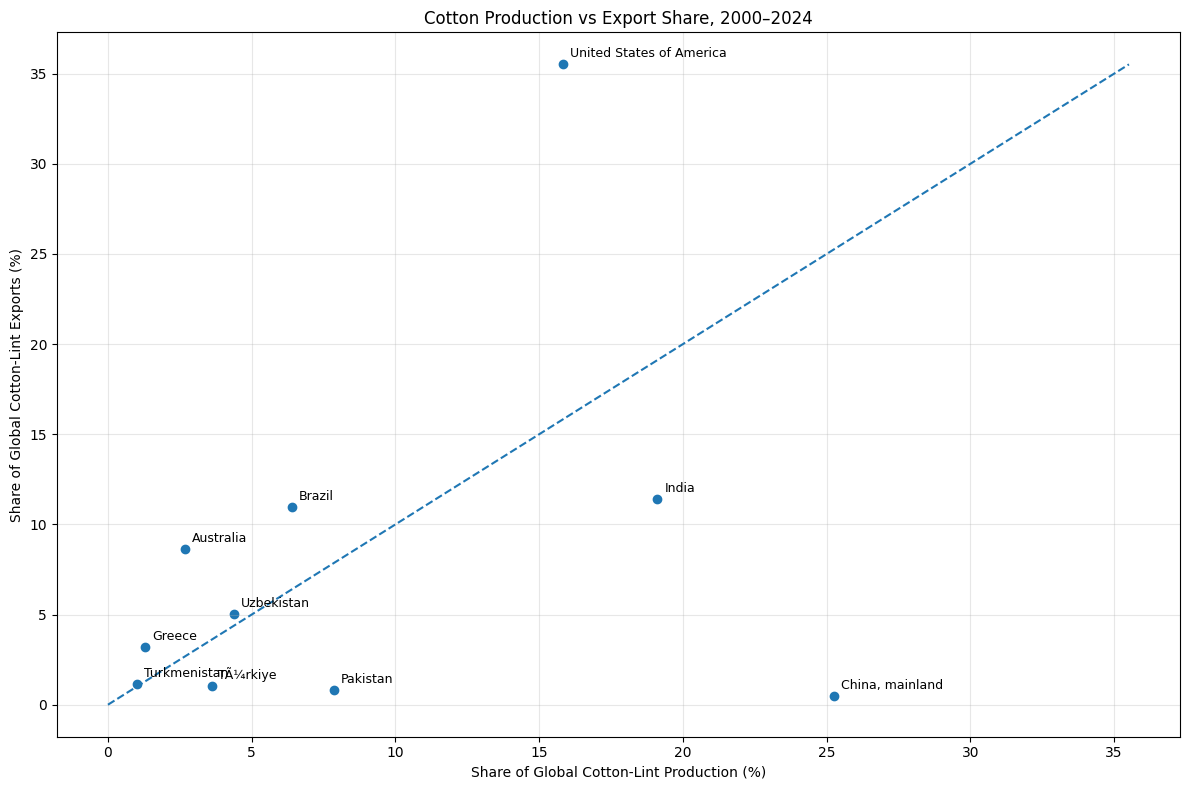

In [93]:
# Your merged production/export dataframe
plot_data = cotton_production_export.copy()

# Keep top 10 producers
plot_data = (
    plot_data
    .sort_values('production_t', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_data['pct_share_production'],
    plot_data['pct_of_world_exports']
)

# Add country labels
for _, row in plot_data.iterrows():
    plt.annotate(
        row['Area'],
        (row['pct_share_production'], row['pct_of_world_exports']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Add diagonal line: export share = production share
max_value = max(
    plot_data['pct_share_production'].max(),
    plot_data['pct_of_world_exports'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--'
)

plt.xlabel('Share of Global Cotton-Lint Production (%)')
plt.ylabel('Share of Global Cotton-Lint Exports (%)')
plt.title('Cotton Production vs Export Share, 2000–2024')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights here:
US:
1. Production share = 15.84%
2. Export share     = 35.52%

China (mainland):
1. Production share = 25.27%
2. Export share     = 0.49%

India:
1. Production share = 19.11%
2. Export share     = 11.42%



### To be discussed:

Rather than focusing on Trade Matrix to udnerstand who buys from these countries, should we go ahead and udensratdn the water stress?
Region wise water stress (Asia, south-asia, americas)
and move ahead with next steps as Daniela mentioned in initial document (predicting 10% , 20% etc)